# USGS 3DEP LiDAR Explorer                                                                                                                                      
Explore high-resolution airborne LiDAR point clouds collected by the U.S. Geological Survey's 3D Elevation Program (3DEP). Each LiDAR dataset captures the height of the ground, vegetation, and structures over a region by recording millions to billions of laser returns from aircraft. This notebook lets you pick a region of interest, download the point cloud, and turn it into a 1-meter digital elevation model (DEM) with hillshade.  
                                                        
The workflow runs in five steps:

1. **Pick an area** — draw a rectangle on the USGS 3DEP coverage map and select a dataset that intersects it from the auto-populated dropdown                            
2. **Download the point cloud** — fetch the LiDAR returns for the selected area from the public Entwine Point Tile (EPT) service
3. **Inspect the point cloud** — point count, elevation range, classification breakdown, and a 3D preview colored by elevation                                           
4. **Generate a DEM and hillshade** — rasterize the ground returns into a 1-meter DEM, then build a shaded relief view                                                   
5. **Visualize** — overlay the locally-computed hillshade against the USGS 3DEP WMS service for wider context

Linked widgets in step 1 are powered by the `sage-bbox-map` and `sage-dropdown` UI skills, which subscribe to changes in kernel variables (`USER_BBOX` triggers the dataset filter automatically when you draw a rectangle). The `usgs-lidar` data skill provides only the data primitives — `fetch_coverage()` and `filter_by_bbox()` — and knows nothing about the UI.                                    
                                                        
No coding needed — just run each cell and follow the prompts.  

In [ ]:
%reset

In [2]:
%%skill
https://github.com/klinucsd/sage_skills/tree/main/topography/usgs-lidar
https://github.com/klinucsd/sage_skills/tree/main/topography/py3dep-dem

In [3]:
%%ask                                                                                                                                                                    
Create a USGS 3DEP coverage map with a bounding box selection tool. 
Show a dropdown of USGS 3DEP datasets that intersect the bounding box 
with under 10 million points.

Let me start by reading the relevant skill files to understand the proper approach.

Now I have all three skill docs. The canonical recipe in `sage-bbox-map` shows exactly how to compose the coverage map + bbox selector + reactive dropdown in one cell. Let me write that script.

Running the script to fetch the coverage catalog, render the bbox map, and create the reactive dropdown.

⟳ Interactive widget — re-run this cell to restore map interactivity.
 Widget callbacks live in the kernel and are lost when the notebook is closed.

⟳ Interactive widget — re-run this cell to restore dropdown interactivity.
 Widget callbacks live in the kernel and are lost when the notebook is closed.

USGS 3DEP Datasets (< 10M points in bbox) Dataset: — Draw a rectangle on the map above to populate this dropdown. —

The script ran successfully. Here's what was set up:

- **Coverage map** — Loaded ** 2,258 USGS 3DEP LiDAR datasets** and rendered an interactive ipyleaflet map with the full 3DEP coverage overlay (blue polygons). You can draw a bounding box anywhere on the map.

- **Reactive dropdown** — Once you draw a rectangle on the map, the dropdown will auto-populate with only those datasets that intersect your bounding box and have ** under 10 million estimated points** (clipped to your bbox). Datasets are sorted alphabetically by name.

**How to use:**
1. Use the rectangle-draw tool (🔲 icon) on the map to select an area of interest.
2. The dropdown below the map will populate with matching 3DEP datasets showing the dataset name and estimated point count.
3. Pick a dataset from the dropdown — its EPT endpoint URL and full metadata will be stored in `SELECTED_3DEP_URL` and `SELECTED_3DEP_DATASET` for use in subsequent cells.

Reading the USGS LiDAR skill for EPT download conventions.

Now I have the skill instructions. Let me write the download and analysis script.

Writing the download + stats + preview script following the skill's Step 3, 4, and 6 patterns.

Running the download and analysis script.

All outputs generated successfully. Let me verify the key files exist.

---

## USGS 3DEP Point Cloud Download — NV_Southern_1_D23

### Download Area

The point cloud was downloaded from the **NV_Southern_1_D23** dataset for the bounding box drawn near latitude 38.86°, longitude −117.32° in Nevada.

---

### Point Count & Elevation

| Metric | Value |
|---|---|
| **Dataset** | NV_Southern_1_D23 |
| **Total points** | 576,774 |
| **Elevation range** | 2,702.40 – 2,785.64 m |
| **Elevation mean** | 2,748.03 m (σ = 19.02 m) |
| **LAZ file size** | 2.7 MB |
| **LAZ file** | `pointcloud.laz` |

---

### Classification Breakdown

| Class | Points | Share |
|---|---|---|
| Unclassified | 396,020 | 68.7% |
| Ground | 180,693 | 31.3% |
| High Noise | 45 | < 0.1% |
| Low Point (noise) | 16 | < 0.1% |


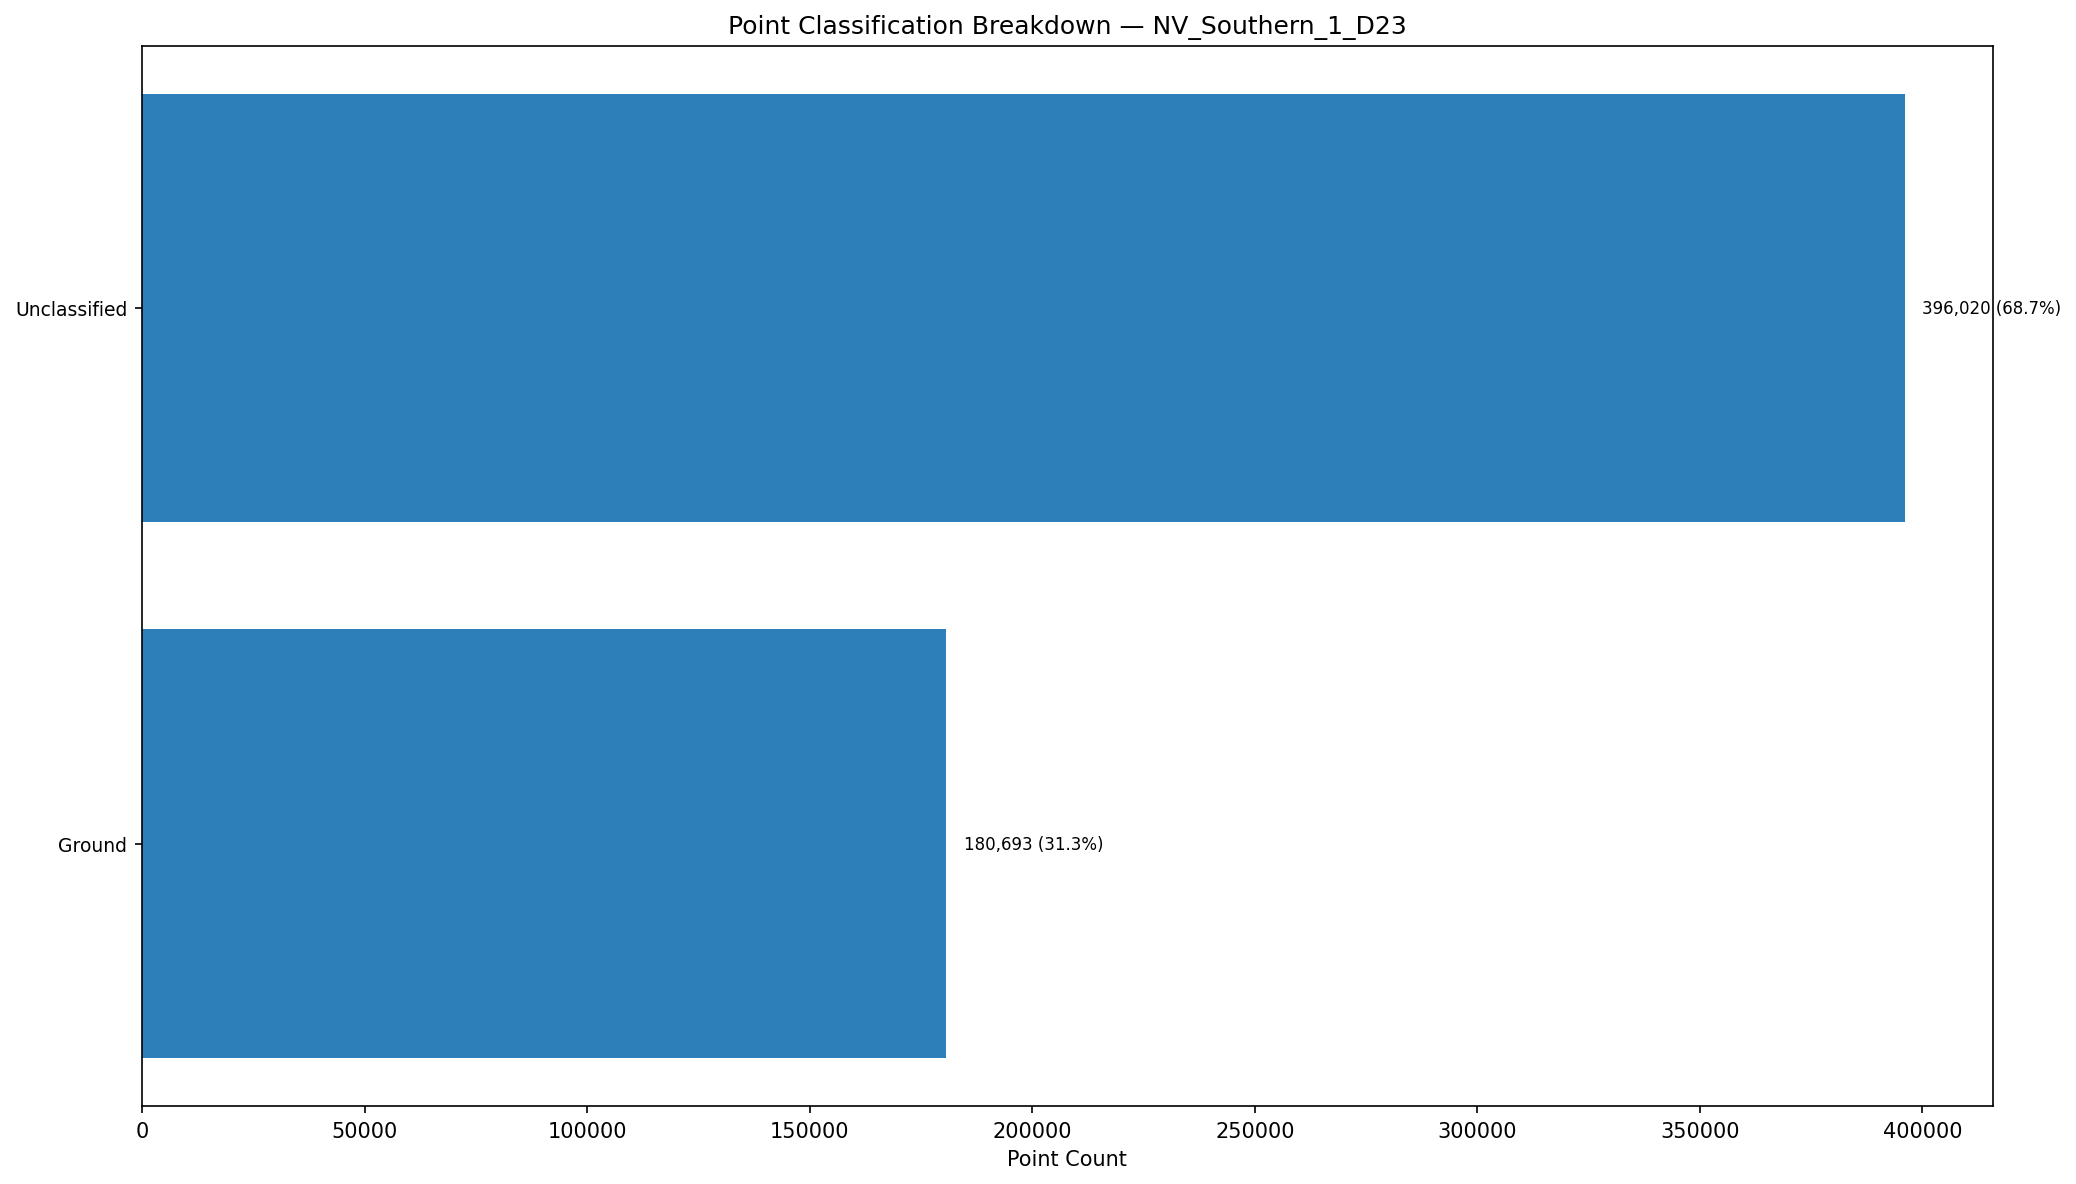

---

### Elevation Preview

The point cloud colored by elevation (terrain colormap). This area sits at roughly 2,700–2,786 m elevation in the Nevada high desert, with a relief of ~83 m across the small bounding box.


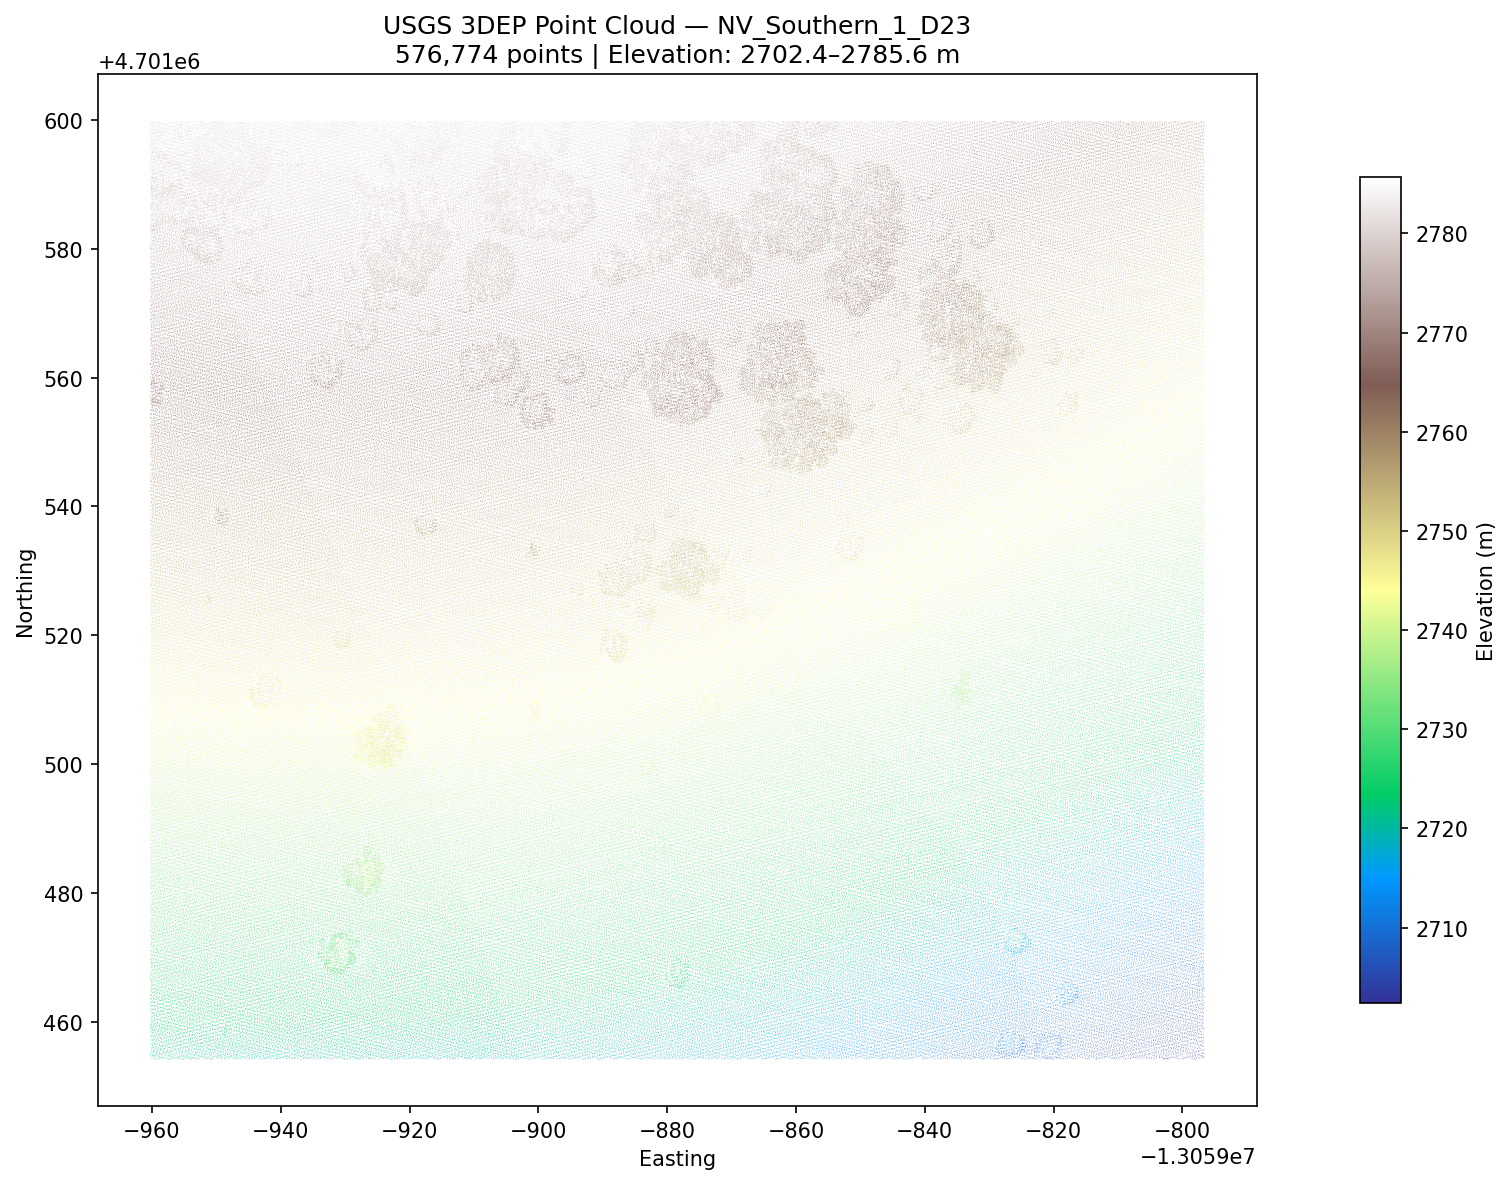

---

### Output Files

All files saved to `/home/jovyan/work/_User-Persistent-Storage_CephBlock_/Sage_demo/_usgs_3dep_sage_/`:

| File | Description |
|---|---|
| `pointcloud.laz` | Compressed LAZ point cloud (576,774 pts) |
| `pointcloud_stats.json` | Full statistics JSON with classification breakdown |
| `pointcloud_elevation_preview.png` | Elevation-colored scatter preview |
| `classification_breakdown.png` | Bar chart of point classifications |
| `download_bbox.geojson` | Bounding box polygon used for the download |

The point cloud is now downloaded and persisted in the kernel as `pointclouds` and on disk as `pointcloud.laz`. The `ept_srs` variable (EPSG:3857) is also stored in the kernel for any subsequent DEM or CHM processing.

In [4]:
%%ask                                                                                                                                                                    
Download the USGS 3DEP point cloud for the selected bounding box as laz file.
Show point count, elevation range, classification breakdown and a preview image 
of the point cloud colored by elevation only.

Let me check the existing kernel variables to understand what's available from the previous cells.

I have the full picture. The previous cell downloaded 576,774 points, saved `pointcloud.laz`, and set `ept_srs` and `pointclouds` in the kernel. Now I'll follow the SKILL.md Step 5 script verbatim to generate a 1-m DEM from ground-classified points and produce a hillshade image.

Running the DEM generation and hillshade script.

Script completed successfully. Let me update the todos and present the results.

## 1-meter DEM from Ground-Classified Points — Results

### DEM Parameters

| Parameter | Value |
|---|---|
| **Dataset** | NV_Southern_1_D23 |
| **CRS** | EPSG:3857 (Web Mercator) |
| **Resolution** | 1 m |
| **Grid size** | 165 × 147 pixels |
| **Ground points used** | 180,693 |
| **Cell coverage** | 94.9% |

### Elevation Statistics

| Metric | Value |
|---|---|
| **Min elevation** | 2,702.48 m |
| **Max elevation** | 2,780.25 m |
| **Mean elevation** | 2,745.65 m |
| **Std deviation** | 18.43 m |
| **Relief** | 77.77 m |

### Output Files

| File | Description |
|---|---|
| `dem_1m.tif` | Georeferenced 1-m DEM (GeoTIFF, EPSG:3857) |
| `hillshade_1m.tif` | Hillshade derived with NW illumination (azimuth 315°, altitude 45°) |
| `hillshade_preview.png` | Grayscale hillshade preview image |
| `hillshade.wms.json` | USGS 3DEP WMS context layer sidecar |

### Hillshade Preview

The hillshade below shows the terrain relief illuminated from the northwest (azimuth 315°, altitude 45°), computed with edge-aware `gdaldem`. The area covers a sloped terrain with ~78 m of relief in central Nevada.


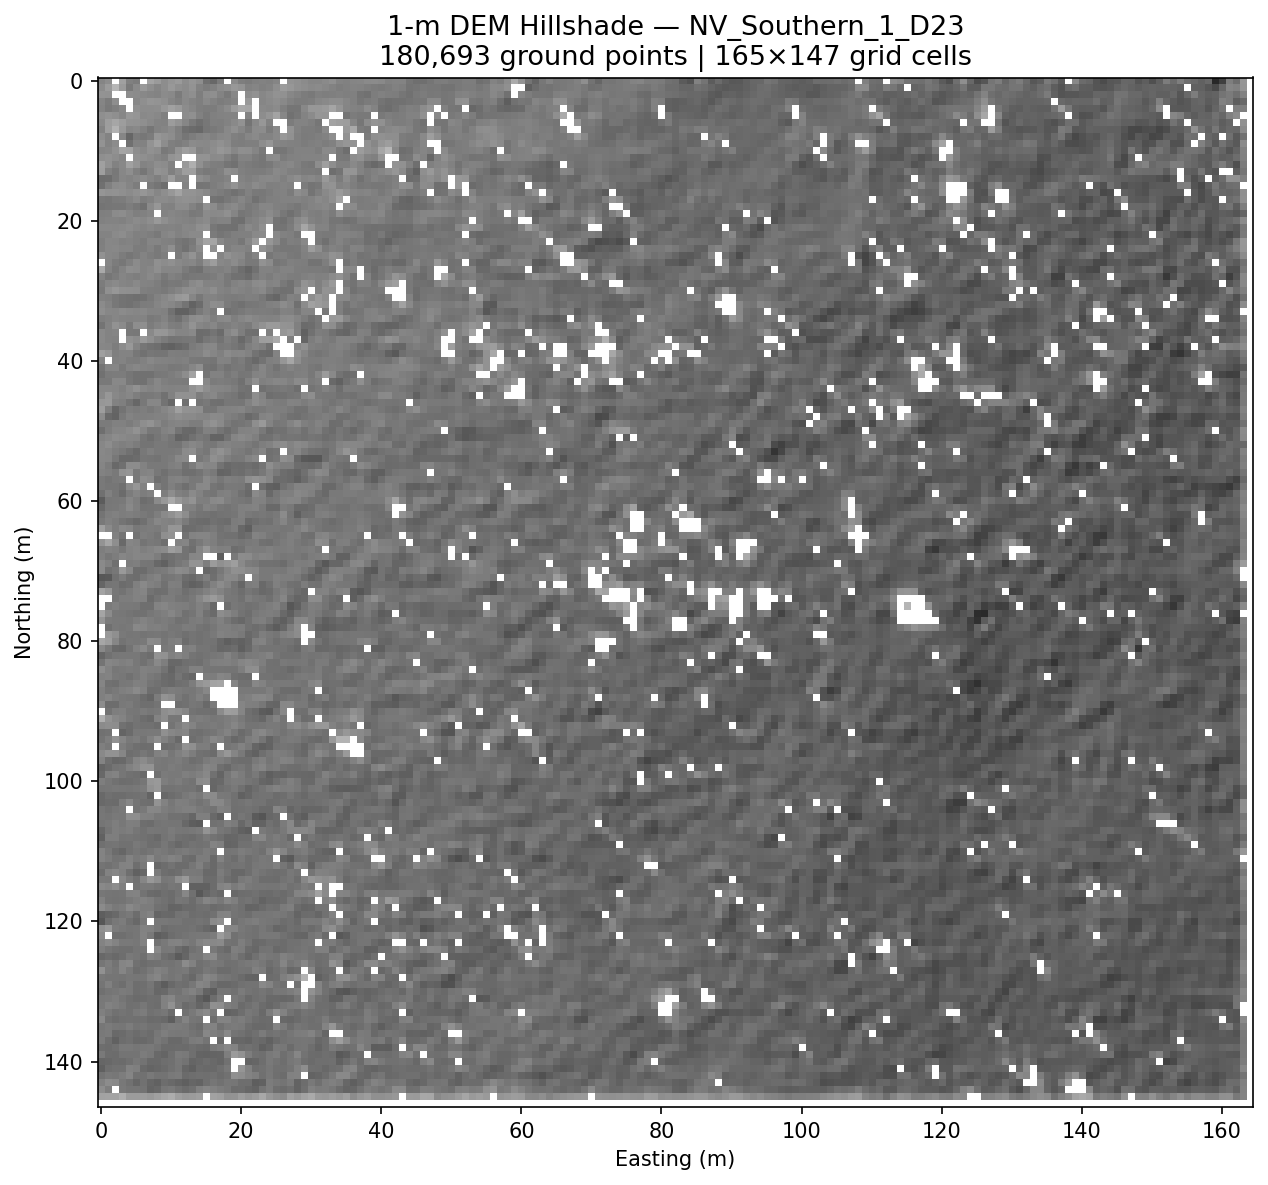

All tasks complete. The 1-m DEM was generated from 180,693 ground-classified points (LAS class 2), rasterized to a 165×147 grid, and rendered as a hillshade with NW illumination. The kernel now holds `dem_tif`, `hillshade_tif`, and `ept_srs` for any downstream processing (e.g., CHM, slope analysis).

In [5]:
%%ask                                                                                                                                                                    
Generate a 1-meter digital elevation model (DEM) from the ground-classified points
in the downloaded laz file, and visualize it as a hillshade image only.

Let me first consult the relevant skills and check the working directory for existing data.

I have the SKILL.md loaded. Step 8 covers CHM generation. Let me write the script following the skill's verbatim pattern, adapting for the kernel variable names.

Writing the CHM generation script following the skill's Step 8 verbatim pattern.

Running the CHM generation script.

The `HeightAboveGround` field is missing. Let me check the array structure and adapt the approach.

...

There IS meaningful canopy height (up to ~5 m). The issue is that my DSM was using all non-ground points' max Z, but the grid-cell averaging for DEM was washing it out. Let me fix the script to properly use per-cell max for DSM and per-cell mean for ground DEM.

I see the bug — `np.maximum.at` on an array initialized with `np.nan` produces all NaN. Need to initialize with `-inf` and then convert to NaN.

Running the fixed CHM script with proper DSM initialization.

CHM generated successfully — max canopy height 8.0 m with 22,970 pixels having height > 0.

## Canopy Height Model (CHM) — Results

The CHM was generated as **DSM minus DEM** at 1-m resolution (the point cloud had no `HeightAboveGround` field, so `pyforestscan.calculate_chm` was not usable). The DSM was built from the per-cell maximum elevation of non-ground points (classes 1, excluding noise), and the DEM from per-cell mean ground elevation (class 2).

### Classification Breakdown

| Class | Label | Points |
|------:|-------|-------:|
| 1 | Unclassified (vegetation/surface) | 396,020 |
| 2 | Ground | 180,693 |
| 7 | Low Noise | 16 |
| 18 | High Noise | 45 |

### CHM Statistics

| Metric | Value |
|--------|-------|
| **Grid size** | 165 × 147 pixels |
| **Resolution** | 1 m |
| **Max canopy height** | 8.0 m |
| **Mean canopy height** | 0.85 m |
| **Median canopy height** | 0.32 m |
| **Valid pixels** | 23,022 |
| **Pixels with height > 0** | 22,970 of 23,022 (99.8%) |
| **DEM elevation range** | 2,702.5 – 2,780.3 m |
| **DSM elevation range** | 2,703.2 – 2,785.6 m |

### Output Files

- **GeoTIFF** : `chm_1m.tif` — georeferenced CHM raster ready for GIS analysis
- **Kernel variables** : `chm`, `chm_extent`, `chm_tif` available for downstream processing

### CHM Preview (colored by canopy height)


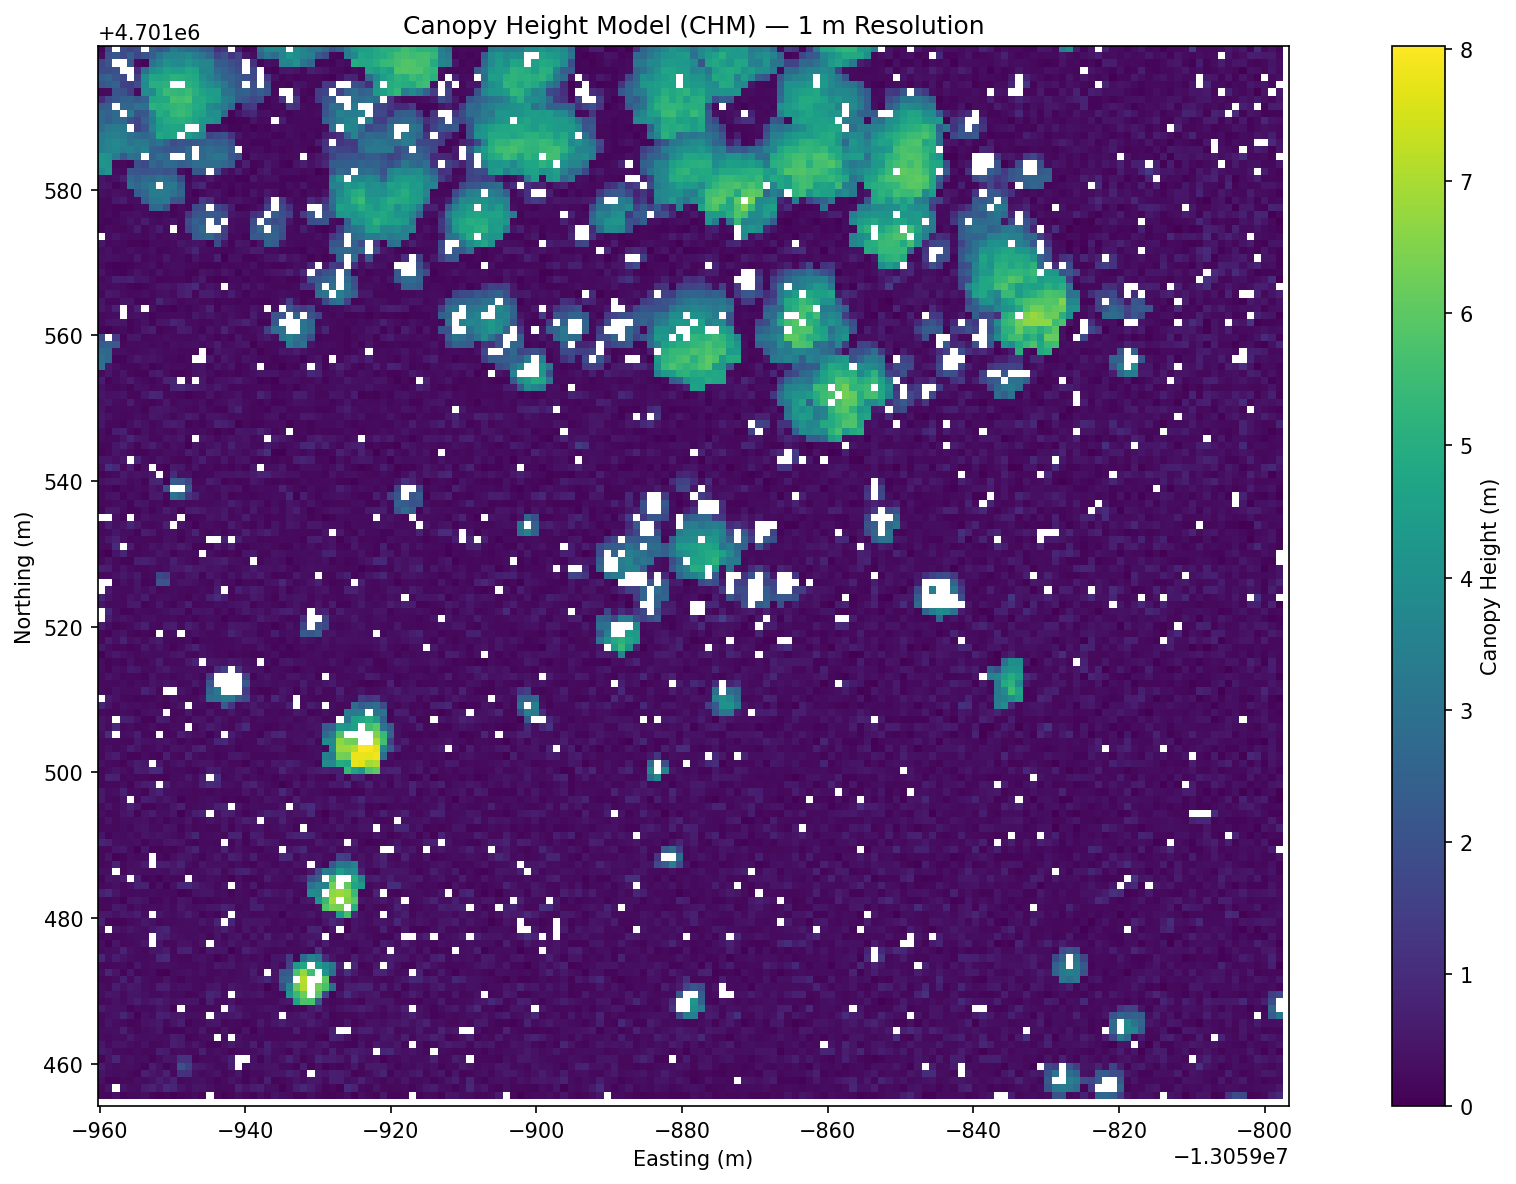

### Height Distribution


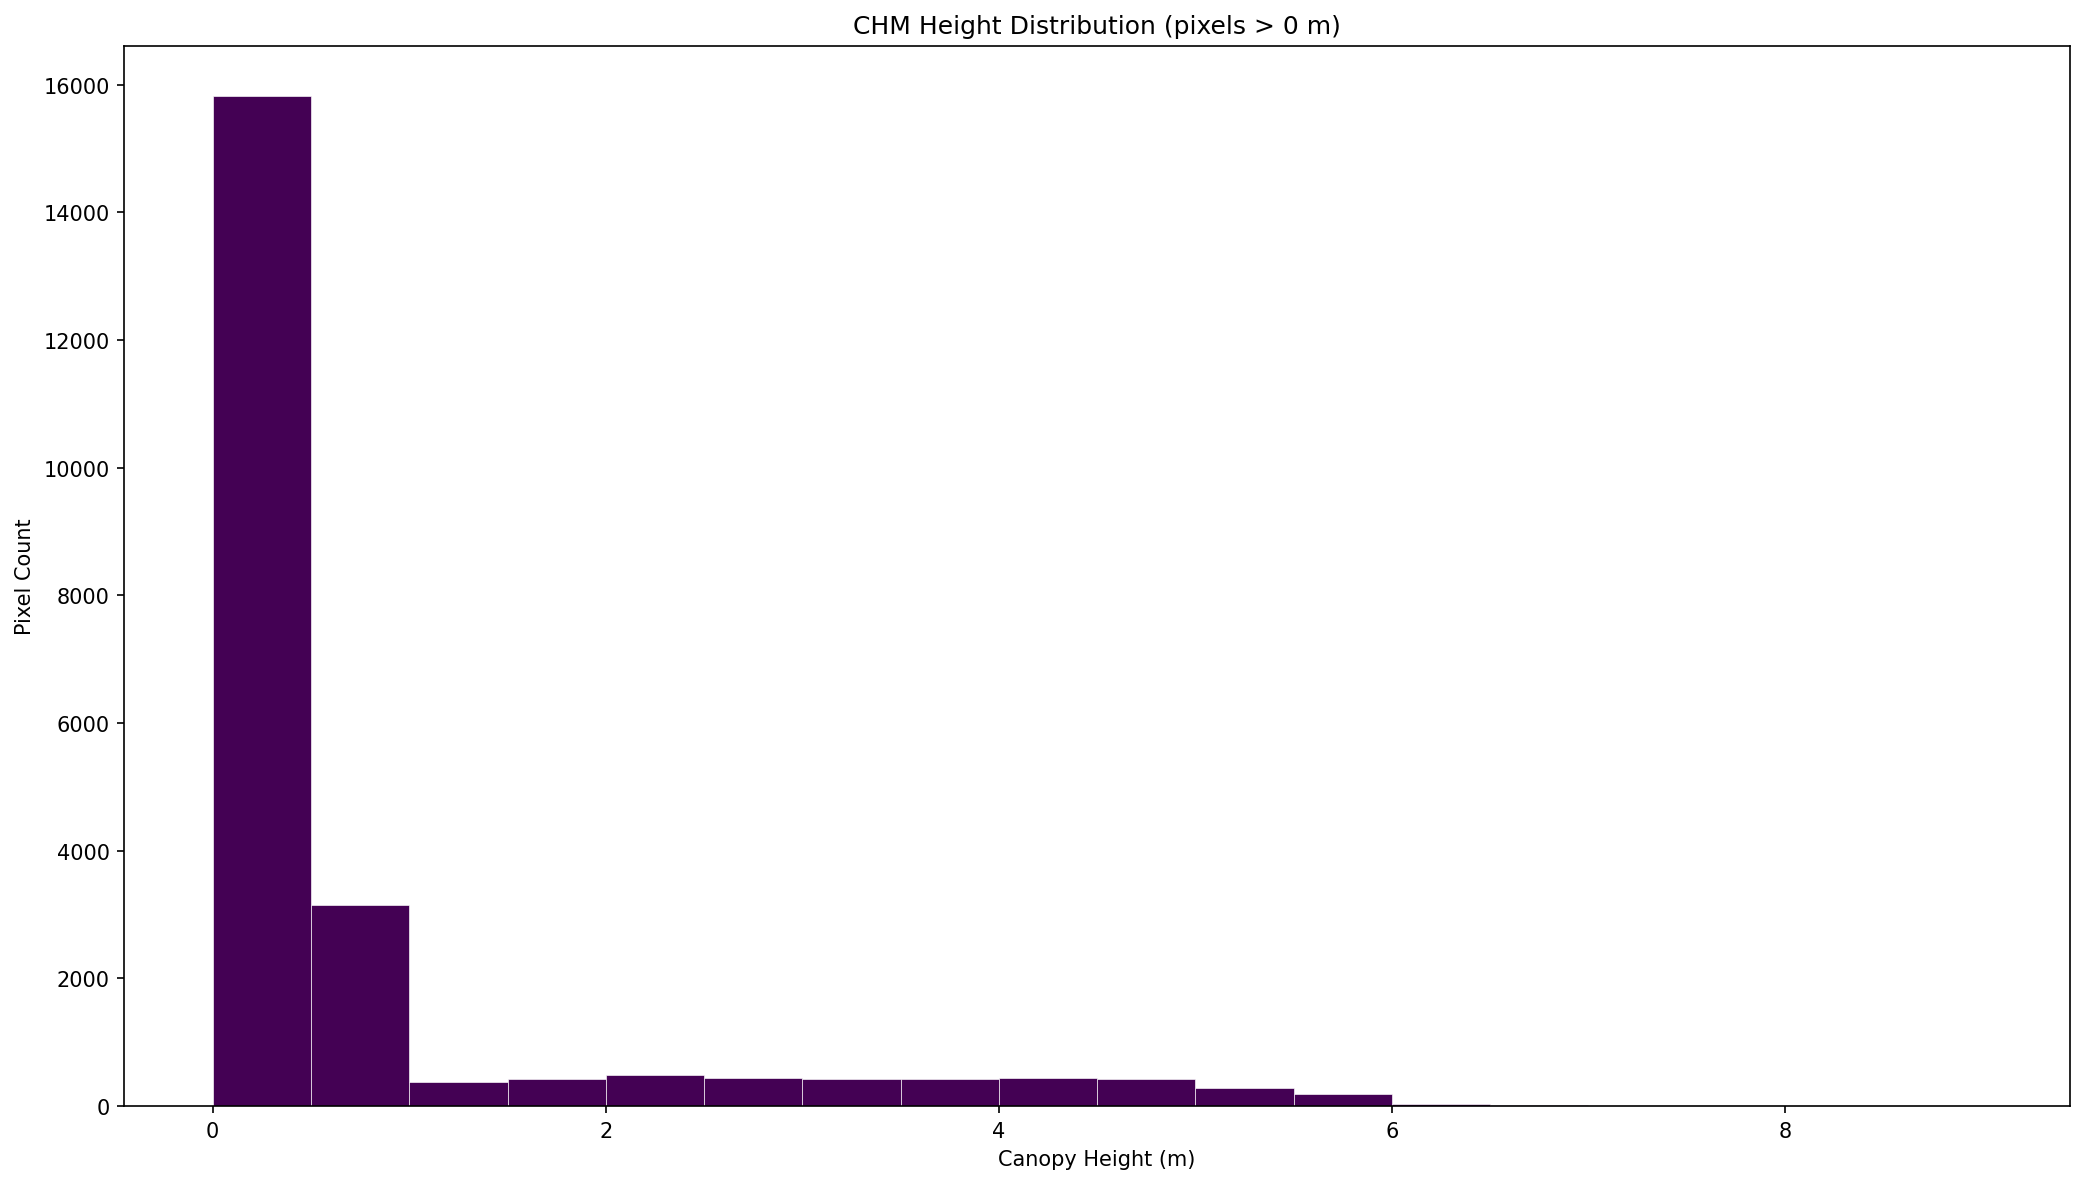

In [6]:
%%ask
Generate CHM from the downloaded point cloud data and 
visualize the CHM results in the usual way